## Проверка гипотезы о том, что новая автоматическая форма платежей ЖКХ услуг приведет к увеличению конверсии из открытия формы к успешной оплате

### Цели и задачи исследования

**Цель** - найти статистическое подтверждение гипотезы, что новая автоматическая форма платежей приведет к увеличению конверсии в оплату

**Задачи:**
* Загрузить данные и ознакомиться с ними
* Провести предобработку данных
* Проверить дизайн эксперимента
* Расчитать исследуемую метрику
* Проверить гипотезу с помощью статистического теста
* Написать выводы по результату A/B - тестирования и дать рекомендации

**Описание данных:**
* Лист1: **Пользователи** ~1 500 строк   **Поля:** Группы A/B, тип устройства, город
* Лист2: **Платежи**      ~2 000 строк   **Поля:** Попытки оплаты ЖКХ за период теста (воронка по шагам)

<a id="section_1"></a>
## 1. Загрузка и знакомство с данными

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.stats.proportion import proportions_ztest

Загрузим данные (оба листа), сохраним в переменной `full_df`

In [2]:
full_df = pd.read_excel('dannye-dlia-keisa-po-pa-cebbefc3-5b29-4f88-b6d4-3336c88d743f.xlsx', sheet_name=None)

In [3]:
print(full_df.keys())

dict_keys(['Пользователи', 'Платежи'])


Каждый лист сохраним в отдельную переменную: `users_df` и `payments_df`, соответственно. Создадим копии листов для работы

In [4]:
users_df = full_df['Пользователи'].copy()   # Таблица с пользователями
payments_df = full_df['Платежи'].copy()     # Таблица с платежами

Познакомимся с данными с помощью методов `info()` и `head()` - выведем общую информацию и первые строки датафрейма

In [5]:
users_df.info()

start_users = len(users_df)
display(f'Количество строк исходного датафрейма: {start_users}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1504 entries, 0 to 1503
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      1504 non-null   int64 
 1   group        1503 non-null   object
 2   age          1504 non-null   int64 
 3   city         1503 non-null   object
 4   device_type  1504 non-null   object
dtypes: int64(2), object(3)
memory usage: 58.9+ KB


'Количество строк исходного датафрейма: 1504'

In [6]:
users_df.head()

,user_id,group,age,city,device_type
0,1001,A,31,Москва,ios
1,1002,A,31,Москва,ios
2,1003,A,25,Москва,android
3,1004,A,20,Москва,ios
4,1005,A,34,Москва,ios


В результате ознакомления с датасетом `users_df` выявлено:

* Датасет `users_df` содержит 1504 строкт и 5 столбцов
* Названия столбцов приведены к общему стилю
* Данные хранятся в корректных типах данных, можно понизить число бит для чисел
* В столбцах `group` и `city` есть по одному пропуску

In [7]:
payments_df.info()

start_payments = len(payments_df)
display(f'Количество строк исходного датафрейма: {start_payments}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2661 entries, 0 to 2660
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   payment_id       2661 non-null   int64         
 1   user_id          2660 non-null   float64       
 2   group            2661 non-null   object        
 3   step1_opened     2661 non-null   datetime64[ns]
 4   step2_entered    2256 non-null   datetime64[ns]
 5   step3_confirmed  1719 non-null   datetime64[ns]
 6   step4_success    1522 non-null   datetime64[ns]
dtypes: datetime64[ns](4), float64(1), int64(1), object(1)
memory usage: 145.6+ KB


'Количество строк исходного датафрейма: 2661'

In [8]:
payments_df.head()

,payment_id,user_id,group,step1_opened,step2_entered,step3_confirmed,step4_success
0,5001,1001.0,A,2024-04-16 06:06:00,2024-04-16 06:10:00,NaT,NaT
1,5002,1002.0,A,2024-04-12 07:38:00,2024-04-12 07:41:00,NaT,NaT
2,5003,1003.0,A,2024-04-26 20:03:00,2024-04-26 20:07:00,NaT,NaT
3,5004,1004.0,A,2024-04-09 16:02:00,NaT,NaT,NaT
4,5005,1004.0,A,2024-04-04 03:46:00,2024-04-04 03:54:00,2024-04-04 03:57:00,2024-04-04 04:02:00


В результате ознакомления с датасетом `payments_df` выявлено:

* Датасет `payments_df` содержит 2661 строкт и 7 столбцов
* Названия столбцов приведены к общему стилю
* Данные хранятся в целом в корректных типах данных, но можно понизить число бит для чисел, привести `user_id` к типу **int**
* В столбцах `user_id` есть один пропуск, в столбцах `step1_opened`, `step2_entered`, `step3_confirmed`, `step4_success` содержатся пропуски. Нужно проверить соответствуют ли они шагу конверсии или являются случайными.

<a id="section_2"></a>
## 2. Предобработка данных

<a id="section_2_1"></a>
### 2.1 Пропуски в данных

In [9]:
# Ищем строки, где в колонках 'group' или 'city' стоят пропуски в датасете users_df
rows_with_gaps = users_df[users_df[['group', 'city']].isna().any(axis=1)]
rows_with_gaps.head()

,user_id,group,age,city,device_type
1500,9001,NaN,25,Москва,ios
1503,9004,A,30,NaN,android


Пропуск в столбце `group` для нас критичен, так как пользователь не относится к ни одной из групп исследования. Пропуск в `city` может некоректно отразить картину распределения пользователей по группам. Строк с пропусками всего две, удалим их из датасета.

In [10]:
# Перезапишем датасет без удаленных строк
users_df = users_df[~users_df[['group', 'city']].isna().any(axis=1)]

In [11]:
# Проверим датасет payments_df по столбцу user_id
rows_with_gaps = payments_df[payments_df['user_id'].isna()]
rows_with_gaps.head()

,payment_id,user_id,group,step1_opened,step2_entered,step3_confirmed,step4_success
2660,99003,NaN,A,2024-04-12 09:15:00,NaT,NaT,NaT


Пропуск в поле `user_id` не несет информации о пользователе, поэтому удалим эту строку из датасета

In [12]:
# Перезапишем датасет без удаленных строк
payments_df = payments_df[~payments_df['user_id'].isna()]

В датасете `payments_df` остались пропуски только в столбцах 2,3,4 шагов воронки оплаты услуг ЖКХ. Так как воронка - это последовательная цепь событий, стоит проверить, последовательно ли идут пропуски. Т.е., убедиться, что пользователь прервался на шаге воронки, а не перепрыгнул через него.

In [13]:
# Найдем строки, где есть проскок шага (например, шаг 3 есть, а шага 2 нет)
anomalies = payments_df[
    (payments_df['step2_entered'].isna() & payments_df['step3_confirmed'].notna()) |
    (payments_df['step3_confirmed'].isna() & payments_df['step4_success'].notna())
]

display(f"Найдено строк с нарушением логики воронки: {len(anomalies)}")

'Найдено строк с нарушением логики воронки: 0'

Раз проскоков в шаге нет, значит все пропуски показывают реальную картину перехода на каждый этап воронки.

<a id="section_2_2"></a>
### 2.2 Оптимизация типов данных

В датасете `payments_df` нужно привести `user_id` к типу **int**. Остальные данные корректные. Данные занимают мало места, поэтому разбер бит можно оставить как есть.

In [14]:
payments_df['user_id'] = payments_df['user_id'].astype('int64', errors='ignore')

display(payments_df['user_id'].dtypes)

dtype('int64')

<a id="section_2_3"></a>
### 2.3 Явные и неявные дубликаты в данных

In [15]:
# Проверим наличие полных дубликатов в датафрейме users_df
users_df.duplicated().sum()

0

In [16]:
# Выведем количество уникальных значений каждого столбца
display(users_df.nunique())

user_id        1502
group             2
age              42
city              3
device_type       2
dtype: int64

In [17]:
# Проверяем уникальные значения в столбцах с небольшим числом уникальных значений
for column in ['group', 'city', 'device_type']:
    display(f'Уникальные значения в столбце {column}:')
    display(users_df[column].sort_values().unique())
    display()

'Уникальные значения в столбце group:'

array(['A', 'B'], dtype=object)

'Уникальные значения в столбце city:'

array(['Москва', 'Регион', 'СПб'], dtype=object)

'Уникальные значения в столбце device_type:'

array(['android', 'ios'], dtype=object)

Количество уникальных пользователей датасета `users_df` совпадает с  числом строк. Уникальные значения в других полях отражены корректно.

In [18]:
# Проверим наличие полных дубликатов в датафрейме payments_df
payments_df.duplicated().sum()

0

In [19]:
# Выведем количество уникальных значений каждого столбца
display(payments_df.nunique())

payment_id         2660
user_id            1501
group                 2
step1_opened       2577
step2_entered      2188
step3_confirmed    1675
step4_success      1489
dtype: int64

In [20]:
# Выведем уникальные значения столбца group
display(payments_df['group'].unique())

array(['A', 'B'], dtype=object)

<a id="section_2_4"></a>
### 2.4 Проверка данных на аномалии и выбросы

Во время поиска дублей, мы проверили корректность полей типа *object*. Теперь проверим распределение данных по числовому полю `age`.

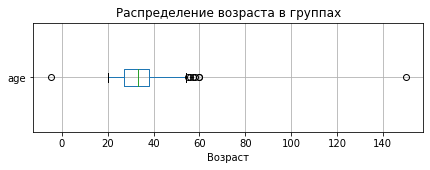

In [21]:
# Зададим размер
plt.figure(figsize=(7, 2))

# Посттроим диаграмму размаха значений
users_df.boxplot(column='age', vert=False)

# Добавим заголовок и метки оси
plt.title('Распределение возраста в группах')
plt.xlabel('Возраст')

# Выведем график
plt.show()

На диаграмме рахмаха видно, что основные данные находятся в возратной группе 25-40 лет, с правосимметричным распределением в сторону более взрослого возраста (50-60 лет), что выглядит корректно. Однако на **диаграмме есть явные выбросы** как в отрицательной части значений, так и в сторону очень высоких значений, выше 150 лет. Можно предположить, что их наличие является ошибкой ввода или техническим сбоем при переносе данных. 

In [22]:
# Фильтруем данные, оставим только положительные значения до возраста 100 лет.
users_df = users_df[(users_df['age'] >= 0) & (users_df['age'] <= 100)]

print(f"Осталось пользователей: {len(users_df)}")

Осталось пользователей: 1500


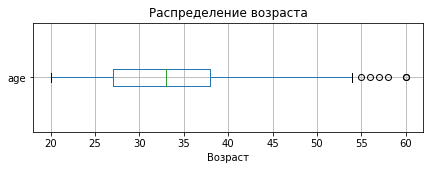

In [23]:
# Проверим как распределены данные после фильтрации
plt.figure(figsize=(7, 2))

users_df.boxplot(column='age', vert=False)

plt.title('Распределение возраста')
plt.xlabel('Возраст')
plt.show()

Теперь столбец `age` чист от аномально выскоких и низких значений. Наличие небольшого числа значений в области 55-60 лет допустим и является показателем, что люди старшего поколения тоже заинтересованы в продукте.  

<a id="section_2_5"></a>
### 2.5 Подготовка единого датафрейма

Для удобства работы с данными, объединим их в общий датафрейм `info_df`:

In [24]:
# Объединим датасеты users_df и payments_df через inner, так как для анализа нужна полная информация
info_df = users_df.merge(payments_df, on='user_id', how='inner')

In [25]:
info_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2659 entries, 0 to 2658
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   user_id          2659 non-null   int64         
 1   group_x          2659 non-null   object        
 2   age              2659 non-null   int64         
 3   city             2659 non-null   object        
 4   device_type      2659 non-null   object        
 5   payment_id       2659 non-null   int64         
 6   group_y          2659 non-null   object        
 7   step1_opened     2659 non-null   datetime64[ns]
 8   step2_entered    2255 non-null   datetime64[ns]
 9   step3_confirmed  1718 non-null   datetime64[ns]
 10  step4_success    1521 non-null   datetime64[ns]
dtypes: datetime64[ns](4), int64(3), object(4)
memory usage: 249.3+ KB


Данные объеденены в общий датасет info_df. Полученный датасет содержит **2659** строк и **11** столбцов, в объеме **249.3+ KB**

Но из-за наличия в обоих датасетах столбца `group` может возникнуть путаница в результатах A/B-теста. Поэтому проверим, совпадают ли значения столбцов `group_x`, `group_y` и приведем к общему виду.

In [26]:
# Считаем, сколько строк, где группа в users_df НЕ совпадает с группой в payments_df
mismatches = info_df[info_df['group_x'] != info_df['group_y']]

print(f"Количество строк с разными группами: {len(mismatches)}")

if len(mismatches) > 0:
    print("Группы не совпадают в некоторых строках. Например:")
    print(mismatches[['user_id', 'group_x', 'group_y']].head())
else:
    print("Группы полностью совпадают. Можно смело удалять один столбец.")

Количество строк с разными группами: 1
Группы не совпадают в некоторых строках. Например:
    user_id group_x group_y
16     1010       A       B


In [27]:
# Оставляем только строки, где группы совпадают
info_df = info_df[info_df['group_x'] == info_df['group_y']]

# Удалим поле group_y, а поле group_x переименуем в group
info_df = info_df.drop(columns=['group_y']).rename(columns={'group_x': 'group'})

In [28]:
info_df.info()

lens_of_df = len(info_df)
display(f'Количество строк исходного датафрейма: {lens_of_df}')

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2658 entries, 0 to 2658
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   user_id          2658 non-null   int64         
 1   group            2658 non-null   object        
 2   age              2658 non-null   int64         
 3   city             2658 non-null   object        
 4   device_type      2658 non-null   object        
 5   payment_id       2658 non-null   int64         
 6   step1_opened     2658 non-null   datetime64[ns]
 7   step2_entered    2254 non-null   datetime64[ns]
 8   step3_confirmed  1717 non-null   datetime64[ns]
 9   step4_success    1520 non-null   datetime64[ns]
dtypes: datetime64[ns](4), int64(3), object(3)
memory usage: 228.4+ KB


'Количество строк исходного датафрейма: 2658'

### Промежуточный вывод

#### В результате предобработки данных:

* Два исходных датасета `users_df`, `payments_df` были объеденены в один общий `info_df`
* Из датасета были удалены 3 строки с **пропусками** в полях: `group`, `city`, `user_id`
* Перед объединением тип данных поля `user_id` был изменен на **integer**
* Данные были проверены на наличие дубликатов. Дубли выявлены не были
* В поле `age` были **обнаружены аномально низкие (отрицательные) и аномально высокие (более 150) значения возраста**. Для исключения аномальных значений по полю была проведена фильтрация. **Остались значения в диапозоне от 0 до 100**.
* В ходе объединения датасетов было выявлено расхождение в столбце `group` одного датасета с другим. Строка с выявленным расхождением была удалена.

Итоговый датасет `info_df` содержит **2658** строк и **10** столбцов, в объеме **228.4+ KB**

<a id="section_3"></a>
## 3. Оценка корректности проведения теста:

**Гипотеза:** упрощенная форма платежей приведет к увеличению конверсии из открытия формы к успешной оплате ЖКХ услуг

<a id="section_3_1"></a>
### 3.1 Оценка распределения пользователей по группам

In [29]:
# Находим количество уникальных пользователей в группe A
group_A = info_df[info_df['group'] == 'A']['user_id'].nunique() 

# Находим количество уникальных пользователей в группe B
group_B = info_df[info_df['group'] == 'B']['user_id'].nunique()

display(f'Группа A: {group_A} пользователей, группа B: {group_B} пользователей')

'Группа A: 750 пользователей, группа B: 750 пользователей'

In [30]:
# Проверяем пересечения пользователей между группами
group_A = info_df[info_df['group'] == 'A']['user_id']
group_B = info_df[info_df['group'] == 'B']['user_id']

intersection = list(set(group_A) & set(group_B))

display(f'Пользователи одновременно в группах A и B: {intersection}')

'Пользователи одновременно в группах A и B: []'

В группах идеальное количественное распределение пользователей по 750 человек в каждой группе. Пересечений между пользователями группы A и группы B нет.

#### Оценим распределение пользователей по городам

In [31]:
# Фильтруем данные, оставялем только группу A
group_a_df = info_df[info_df['group'] == 'A']

display('Города группы A:')

# Посчитаем количество и долю пользователей по устройствам
count_a_city = group_a_df.groupby('city')['user_id'].nunique()
total_a_city = group_a_df['user_id'].nunique()

shere_a_city = count_a_city/total_a_city

# Создаем отдельный датафрейм с количеством и долей
df_a_city = pd.DataFrame({'Абс_количество':count_a_city,
                            'Отн_количество':shere_a_city})
display(df_a_city)

'Города группы A:'

,Абс_количество,Отн_количество
city,,
Москва,288,0.384000
Регион,268,0.357333
СПб,194,0.258667


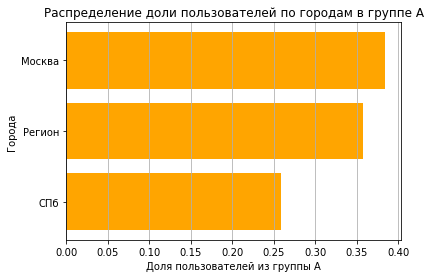

In [32]:
# Строим линейчатую диаграмму для группы A
plt.figure(figsize=(6, 4))

# Сортируем датафрейм по доле пользователей 
df_sorted_a1 = df_a_city.sort_values('Отн_количество', ascending=True)

# index — города, shere_a — доли 
plt.barh(df_sorted_a1.index, df_sorted_a1['Отн_количество'], color='orange')  

plt.xlabel('Доля пользователей из группы A')
plt.ylabel('Города')

plt.title('Распределение доли пользователей по городам в группе A')

plt.grid(axis='x')
plt.show()

In [33]:
# Фильтруем данные, оставялем только группу A
group_b_df = info_df[info_df['group'] == 'B']

display('Города группы B:')

# Посчитаем количество и долю пользователей по устройствам
count_b_city = group_b_df.groupby('city')['user_id'].nunique()
total_b_city = group_b_df['user_id'].nunique()

shere_b_city = count_b_city/total_b_city

# Создаем отдельный датафрейм с количеством и долей
df_b_city = pd.DataFrame({'Абс_количество':count_b_city,
                            'Отн_количество':shere_b_city})
display(df_b_city)

'Города группы B:'

,Абс_количество,Отн_количество
city,,
Москва,306,0.408000
Регион,245,0.326667
СПб,199,0.265333


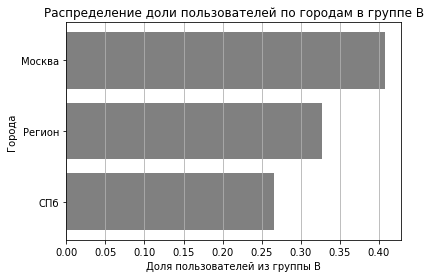

In [34]:
# Строим линейчатую диаграмму для группы A
plt.figure(figsize=(6, 4))

# Сортируем датафрейм по доле пользователей 
df_sorted_b1 = df_b_city.sort_values('Отн_количество', ascending=True)

# index — города, shere_a — доли 
plt.barh(df_sorted_b1.index, df_sorted_b1['Отн_количество'], color='grey')  

plt.xlabel('Доля пользователей из группы B')
plt.ylabel('Города')

plt.title('Распределение доли пользователей по городам в группе B')

plt.grid(axis='x')
plt.show()

Распределение по городам между группами равномерное

#### Оценим распределение пользователей по типу устройств

In [35]:
display('Типы устройств группы A:')

# Посчитаем количество и долю пользователей по устройствам
count_a_device = group_a_df.groupby('device_type')['user_id'].nunique()
total_a_device = group_a_df['user_id'].nunique()

shere_a_device = count_a_device/total_a_device

# Создаем отдельный датафрейм с количеством и долей
df_a_device = pd.DataFrame({'Абс_количество':count_a_device,
                            'Отн_количество':shere_a_device})
display(df_a_device)

'Типы устройств группы A:'

,Абс_количество,Отн_количество
device_type,,
android,406,0.541333
ios,344,0.458667


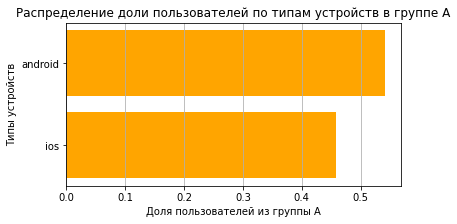

In [36]:
# Строим линейчатую диаграмму для группы A
plt.figure(figsize=(6, 3))

# Сортируем датафрейм по доле пользователей 
df_sorted_a1 = df_a_device.sort_values('Отн_количество', ascending=True)

# index — города, shere_a — доли 
plt.barh(df_sorted_a1.index, df_sorted_a1['Отн_количество'], color='orange')  

plt.xlabel('Доля пользователей из группы A')
plt.ylabel('Типы устройств')

plt.title('Распределение доли пользователей по типам устройств в группе A')

plt.grid(axis='x')
plt.show()

In [37]:
display('Типы устройств группы B:')

# Посчитаем количество и долю пользователей по устройствам
count_b_device = group_b_df.groupby('device_type')['user_id'].nunique()
total_b_device = group_b_df['user_id'].nunique()

shere_b_device = count_b_device/total_b_device

# Создаем отдельный датафрейм с количеством и долей
df_b_device = pd.DataFrame({'Абс_количество':count_b_device,
                            'Отн_количество':shere_b_device})
display(df_b_device)

'Типы устройств группы B:'

,Абс_количество,Отн_количество
device_type,,
android,369,0.492
ios,381,0.508


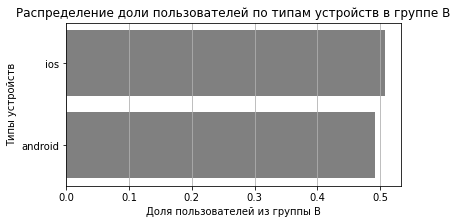

In [38]:
# Строим линейчатую диаграмму для группы B
plt.figure(figsize=(6, 3))

# Сортируем датафрейм по доле пользователей 
df_sorted_b1 = df_b_device.sort_values('Отн_количество', ascending=True)

# index — тип устройства, shere_b — доли 
plt.barh(df_sorted_b1.index, df_sorted_b1['Отн_количество'], color='grey')  

plt.xlabel('Доля пользователей из группы B')
plt.ylabel('Типы устройств')

plt.title('Распределение доли пользователей по типам устройств в группе B')

plt.grid(axis='x')
plt.show()

Распределение по типам устройств в группах A и B сопоставимо (разница менее 5%), это позволяет проводить сравнение конверсии.

#### Оценим распределение пользователей по возрасту

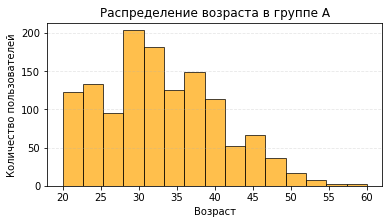

In [39]:
# Распределение возраста в группе A
plt.figure(figsize=(6, 3))
plt.hist(info_df[info_df['group'] == 'A']['age'], 
         bins=15, color='orange', edgecolor='black', alpha=0.7)
plt.title('Распределение возраста в группе A')
plt.xlabel('Возраст')
plt.ylabel('Количество пользователей')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()  

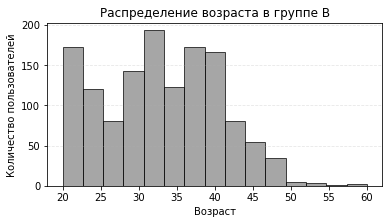

In [40]:
# Распределение возраста в группе B
plt.figure(figsize=(6, 3))
plt.hist(info_df[info_df['group'] == 'B']['age'], 
         bins=15, color='grey', edgecolor='black', alpha=0.7)
plt.title('Распределение возраста в группе B')
plt.xlabel('Возраст')
plt.ylabel('Количество пользователей')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show() 

Распределение возрастов между группами сопоставимо.

<a id="section_3_2"></a>
### 3.2 Выбор статистического теста

Сделаем предварительный расчет конверсии в оплату в каждой из групп и сравним результаты

In [41]:
# Фильтруем данные, оставялем только группу A
group_a_df = info_df[info_df['group'] == 'A']

# Находим количество уникальных пользователей на шаге 1 в группe A
step1_a_count = group_a_df['step1_opened'].count()

# Находим количество уникальных пользователей на шаге 4 в группe A
step4_a_count = group_a_df['step4_success'].count()

# Считаем конверсию в оплату для группы A
share_a = round(step4_a_count/step1_a_count, 4)
display(f'В группе A из {step1_a_count} заходов в форму, {step4_a_count} - успешных оплат. Конверсия в оплату составляет {share_a}')

'В группе A из 1307 заходов в форму, 650 - успешных оплат. Конверсия в оплату составляет 0.4973'

In [42]:
# Фильтруем данные, оставялем только группу B
group_b_df = info_df[info_df['group'] == 'B']

# Находим количество уникальных пользователей на шаге 1 в группe B
step1_b_count = group_b_df['step1_opened'].count()

# Находим количество уникальных пользователей на шаге 4 в группe B
step4_b_count = group_b_df['step4_success'].count()

# Считаем конверсию в оплату для группы B
share_b = round(step4_b_count/step1_b_count, 4)
display(f'В группе B из {step1_b_count} заходов в форму, {step4_b_count} - успешных оплат. Конверсия в оплату составляет {share_b}')

'В группе B из 1351 заходов в форму, 870 - успешных оплат. Конверсия в оплату составляет 0.644'

In [43]:
rel_diff_conversion = round((share_b - share_a)*100, 4)
abs_diff_conversion = step4_b_count - step4_a_count

display(f'Разница в конверсиях составляет {abs_diff_conversion} оплат или {rel_diff_conversion} %')

'Разница в конверсиях составляет 220 оплат или 14.67 %'

**Предварительный вывод**

На этапе предварительного расчета метрик, можно замтить, что разница в конверсиях между контрольной и тестовой группами составляет 220 оплат или 14.67%. Эта разница является положительной для возможного принятия альтернативной гипотезы, но требует проверку на статистическую значимость.

Так как мы изучаем долевую метрику, лучшим выбором для статистического теста будет Z-тест пропорций

Зададим стандартные параметры:
* Уровень значимости - 5%
* Мощность теста - 80%

<a id="section_4"></a>
## 4. Оценка результатов A/B-тестирования:

Формулировка нулевой и альтернативной гипотез

* **Нулевая гипотеза:** Конверсия в оплату пользователей группы A (контрольная) и группы B (тестовая) равны.

* **Альтернативная гипотеза:** Конверсия в оплату группы A (контрольная) меньше конверсии группы B (тестовая)

In [44]:
# Проводим Z-тест пропорций

# Данные для теста
step4 = [step4_a_count, step4_b_count]  # число успешных оплат в группах A и B на шаге 4
step1 = [step1_a_count, step1_b_count]    # число открытий формы оплаты в группах A и B на шаге 1

alpha = 0.05  # уровень значимости

stat_ztest, p_value_ztest = proportions_ztest(step4, step1, alternative='smaller')

# Выводим результаты
print(f"Доля успешных первых сессий (группа A): {round(share_a, 4)}")
print(f"Доля успешных первых сессий (группа B): {round(share_b, 4)}")
print(f"Z‑статистика (отклонение от среднего): {round(stat_ztest, 4)}")

# Интерпретация результата
if p_value_ztest > alpha:
    print(f'p-value = {round(p_value_ztest, 4)} > {alpha}')
    print("Вывод: Различие не является статистически значимым. Не имеем достаточных оснований для отклонения нулевой гипотезы")
else:
    print(f'p-value = {round(p_value_ztest, 4)} < {alpha}')
    print("Вывод: Различие статистически значимо. Отвергаем нулевую гипотезу")

Доля успешных первых сессий (группа A): 0.4973
Доля успешных первых сессий (группа B): 0.644
Z‑статистика (отклонение от среднего): -7.6387
p-value = 0.0 < 0.05
Вывод: Различие статистически значимо. Отвергаем нулевую гипотезу


#### Вывод по результатам A/B-тестирования

Для проверки новой формы оплаты с автозаполнением реквизитов, был проведен **A/B-тест с участием по 750 пользователей в обеих группах**. В качестве **целевой метрики** выбрано **увеличение конверсии в оплату** у тестовой группы (В) по сравнению с контрольной (A). В качестве статистического теста для проверки результатов A/B-тестирования выбран **Z-тест пропорций**.

Значение **p-value оказалось меньше значения уровня статистической значимости, и равно 0.0**, поэтому в результате теста **нулевая гипотеза была отвергнута**. Это означает, что на текущих данных **удалось обнаружить статистически значимое различие** между конверсиями групп A и B.

Так как **альтернативная гипотеза нашла статистическое подтверждение**, можно сказать что **нововведение** в представленном виде на текущих данных **оказалось эффективным**.

<a id="section_5"></a>
## 5. Рекомендации на основе результатов анализа

1. По итогу исследования, мы получили **прирост конверсии в оплату на 14.67%** и **подтверждили это Z-статистикой с p-value = 0.0**. Это означает, что автозаполнение реквизитов значительно упростило оплату ЖКХ услуг. Учитывая уверенно хорошие показатели новой формы, ее **можно внедрять на всю аудиторию пользователей сервиса**.

2. **Перед внедрением необходимо проверить технический бэграунд**: убедиться, что все реквизиты подставляются верно, и оплаты всех пользователей поступают по назначению.

3. Ввиду низкого процента оплат контрольной группы, следует убедиться, **корректно ли работает контрольная (старая) форма оплаты**. Так как ЖКХ являются обязятельными ежемесячными платежами, с большой вероятностью в форму приемущественно заходят те пользователи, которые намерены совершить оплату.

4. Можно более **подробно изучить, на какой из платформ новая форма дала больший прирост**. Проверить корректность и удобство автозаполнения в зависимости от платформы (android, ios)